# Практическая работа: Линейная регрессия на данных о продаже автомобилей

# Задание: шаг за шагом выполнить анализ данных и построить модель линейной регрессии.
# В ячейках ниже даны подсказки, а код вам нужно дописать самостоятельно.

# 1. Импортируйте необходимые библиотеки:
# - pandas
# - matplotlib.pyplot
# - seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Загрузите датасет "car_data.csv" и выведите первые 5 строк таблицы.

In [ ]:
data=pd.read_csv('car_data.csv')

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# 3. Выведите общую информацию о данных (тип данных, количество строк, столбцов).

In [ ]:
data.shape

(301, 9)

In [ ]:
data.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


# 4. Проверьте наличие пропусков в таблице.

In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


# 5. Посмотрите описательные статистики числовых признаков.

In [ ]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# 6. Выведите список всех колонок.

In [ ]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

# 7. Определите количество значений в категориальных признаках:
# - Fuel_Type
# - Seller_Type
# - Transmission

In [ ]:
data['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [ ]:
data['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [ ]:
data['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [ ]:
fuel_type = data['Fuel_Type']
seller_type = data['Seller_Type']
transmission_type = data['Transmission']
selling_price = data['Selling_Price']

# 8. Визуализируйте распределение продаж (Selling_Price) в зависимости от категориальных признаков. Используйте matplotlib и seaborn (barplot).

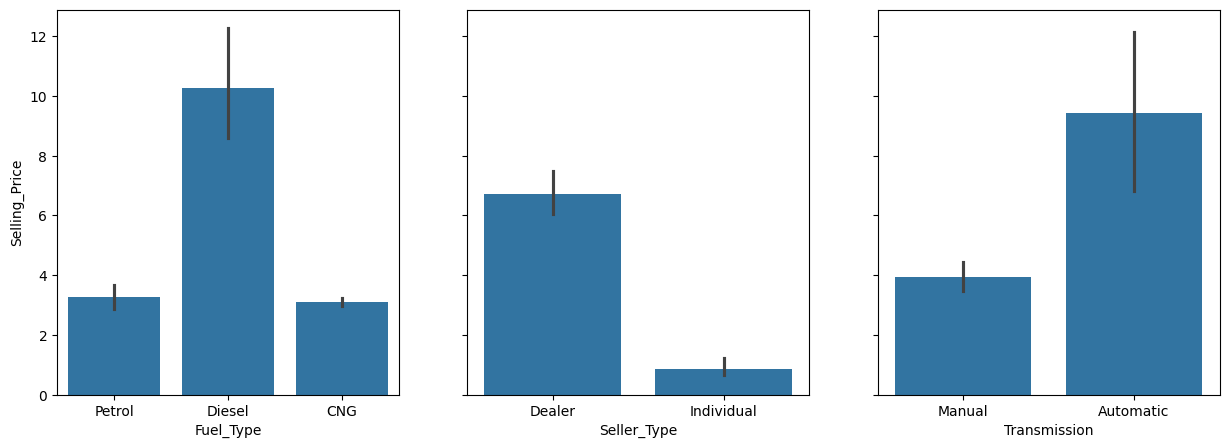

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
sns.barplot(x='Fuel_Type', y='Selling_Price', data=data, ax=axes[0])
sns.barplot(x='Seller_Type', y='Selling_Price', data=data, ax=axes[1])
sns.barplot(x='Transmission', y='Selling_Price', data=data, ax=axes[2])
plt.show()

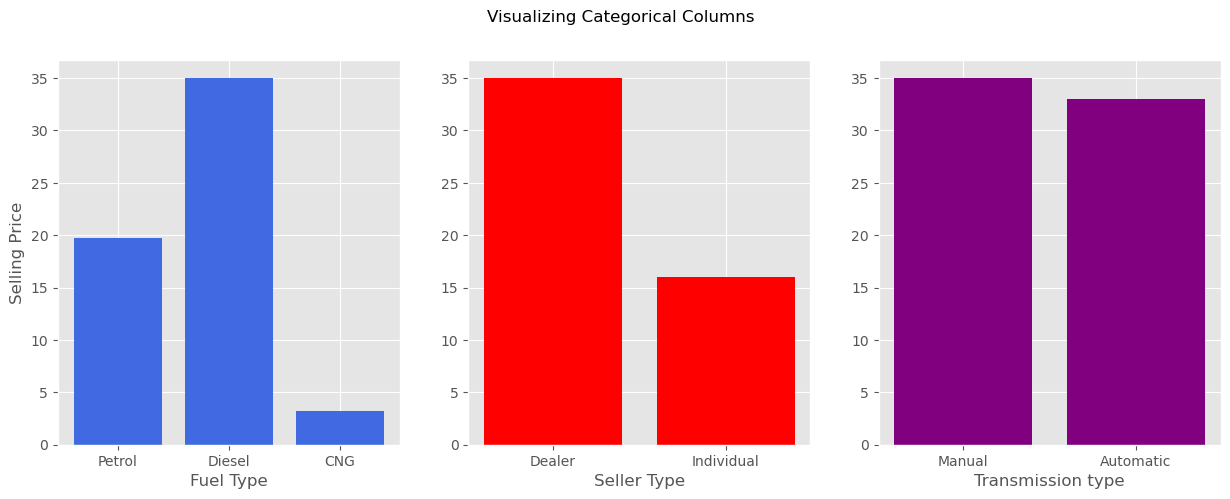

<AxesSubplot:xlabel='Transmission', ylabel='Selling_Price'>

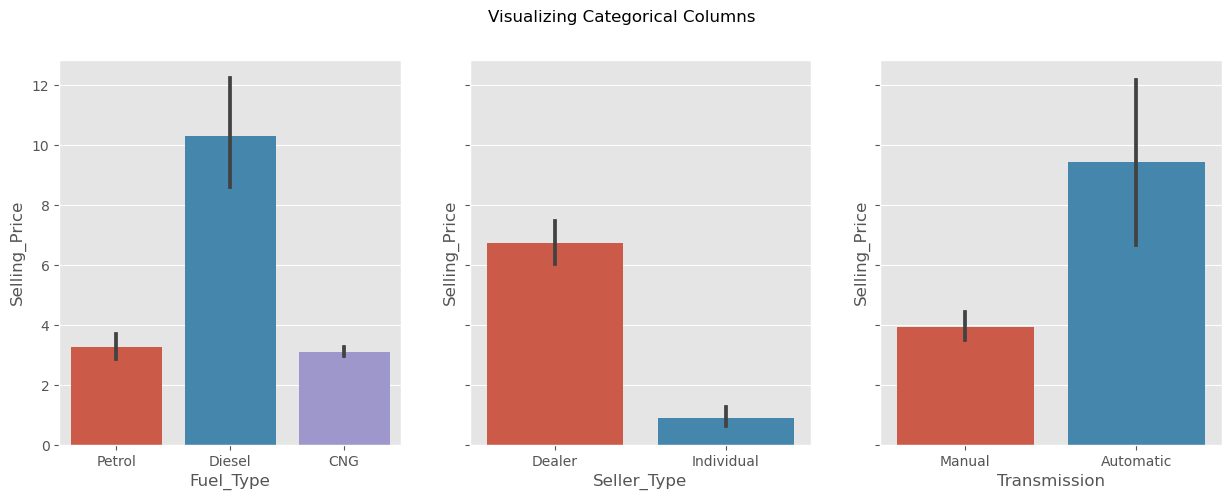

In [ ]:
#your code here

# 9. Сгруппируйте данные по 'Fuel_Type' и отдельно проанализируйте статистику для бензиновых машин.

In [ ]:
fuel_type_grouped = data.groupby('Fuel_Type')
display(fuel_type_grouped.get_group('Petrol').describe())

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,239.000000,239.000000,239.000000,239.000000,239.000000
mean,2013.539749,3.264184,5.583556,33528.937238,0.050209
std,3.042674,3.135537,5.290685,40308.984886,0.270368
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.600000,0.940000,13850.000000,0.000000
50%,2014.000000,2.650000,4.600000,25870.000000,0.000000
75%,2016.000000,5.200000,7.980000,44271.000000,0.000000
max,2017.000000,19.750000,23.730000,500000.000000,3.000000


# 10. Сгруппируйте данные по 'Seller_Type' и посмотрите статистику для продавцов-«Dealer».

In [ ]:
seller_type_grouped = data.groupby('Seller_Type')
display(seller_type_grouped.get_group('Dealer').describe())

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,195.000000,195.000000,195.000000,195.000000,195.000000
mean,2013.712821,6.721692,10.886308,39850.133333,0.020513
std,2.686275,5.136088,8.806563,24860.401003,0.142111
min,2003.000000,1.050000,2.690000,2071.000000,0.000000
25%,2012.000000,3.750000,6.580000,22148.500000,0.000000
50%,2014.000000,5.250000,8.500000,39485.000000,0.000000
75%,2016.000000,7.625000,13.460000,51785.500000,0.000000
max,2018.000000,35.000000,92.600000,197176.000000,1.000000


# 11. Преобразуйте категориальные переменные в числовые:
# - Fuel_Type: Petrol=0, Diesel=1, CNG=2
# - Seller_Type: Dealer=0, Individual=1
# - Transmission: Manual=0, Automatic=1

In [ ]:
data['Fuel_Type'].replace({'Petrol': 0, 'Diesel': 1, 'CNG': 2}, inplace=True)

/tmp/ipython-input-1942302531.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Fuel_Type'].replace({'Petrol': 0, 'Diesel': 1, 'CNG': 2}, inplace=True)


In [ ]:
data['Seller_Type'].replace({'Dealer': 0, 'Individual': 1}, inplace=True)

/tmp/ipython-input-3370395973.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Seller_Type'].replace({'Dealer': 0, 'Individual': 1}, inplace=True)


In [ ]:
data['Transmission'].replace({'Manual': 0, 'Automatic': 1}, inplace=True)

/tmp/ipython-input-3105309650.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Transmission'].replace({'Manual': 0, 'Automatic': 1}, inplace=True)


In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


# 12. Постройте корреляционную матрицу и визуализируйте её с помощью heatmap.

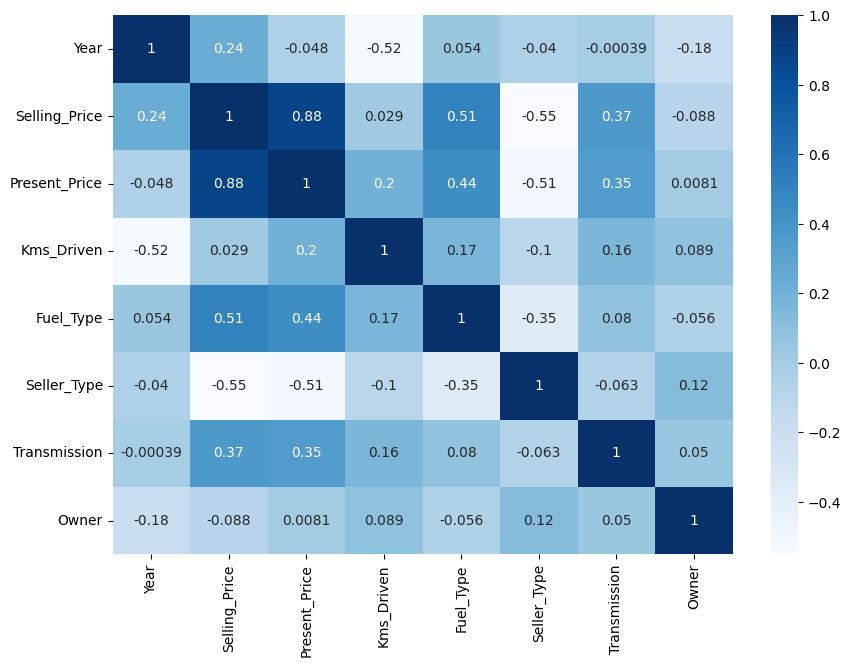

In [ ]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.show()

# 13. Постройте регрессионный график зависимости Selling_Price от Present_Price.

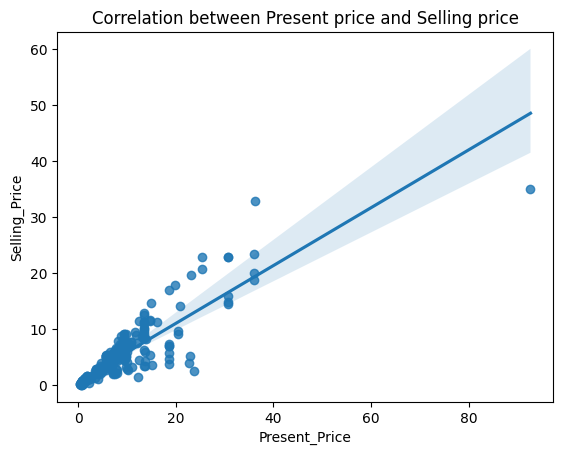

In [ ]:
sns.regplot(x='Present_Price', y='Selling_Price', data=data)
plt.title('Correlation between Present price and Selling price')
plt.show()

<AxesSubplot:title={'center':'Correlation between Present price and Selling price'}, xlabel='Present_Price', ylabel='Selling_Price'>

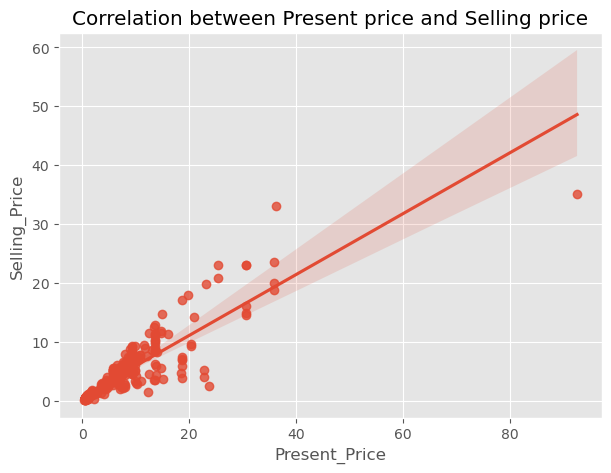

# 14. Создайте матрицы признаков (X) и целевой переменной (y). Удалите из X колонки 'Car_Name' и 'Selling_Price'.

In [ ]:
X = data.drop(['Car_Name', 'Selling_Price'], axis=1)
y = data['Selling_Price']

In [ ]:
display(X.shape)
display(y.shape)

(301, 7)

(301,)

# 15. Разделите данные на обучающую и тестовую выборки (train_test_split).
# Размер тестовой выборки — 30%, random_state=43.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43)
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(210, 7)

(91, 7)

(210,)

(91,)

# 16. Нормализуйте данные с помощью StandardScaler.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 17. Обучите модель линейной регрессии (LinearRegression).

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

# 18. Сделайте предсказания для тестовой выборки.

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
#your code here

LinearRegression()

# Прогнозирование результата

In [ ]:
display(y_pred)

array([ 7.68837102,  2.00752831,  5.92547037, -0.22390694,  0.62281431,
        8.90036753,  0.76457383, 17.0277428 ,  8.26881022,  0.31864421,
        2.28795136, 21.66106378,  4.53818811,  7.68098776,  6.93995738,
        1.79351942,  8.1002021 ,  2.95782685,  6.26956426,  7.80951331,
        3.16544612,  4.75862767,  4.35002046,  5.15056019, 11.37157116,
        8.78745414,  7.72278249,  5.63991075, 11.14274127,  2.69539767,
        3.90628681,  5.20603602,  8.64454974, 18.17480024,  4.25396679,
        2.11286943,  7.60509886,  2.10344824,  0.52755392,  0.31353662,
        3.32294476, 20.04095476,  6.56408773,  1.65699687, -0.54803264,
        4.52018919,  3.94578973,  2.47871278,  1.11454052,  2.73599869,
        6.68207655,  3.04490227,  3.62714368,  6.26655243,  1.47397748,
        1.51657441, -0.26126322,  5.94527335,  7.64377664,  9.98789983,
        0.8266805 ,  8.26881022,  4.82835267, 10.3055492 ,  6.49797273,
        4.57740321,  2.67009966,  2.44061297,  6.51394694,  0.20

# 19. Посчитайте метрики качества модели:
# - MAE
# - MSE
# - R2

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE: ', mae)
print('MSE: ', mse)
print('R2 score: ', r2)

MAE:  1.4308902766497633
MSE:  5.167492869813309
R2 score:  0.8385549491623852


# 20. Постройте график "Предсказанные значения vs Фактические значения".

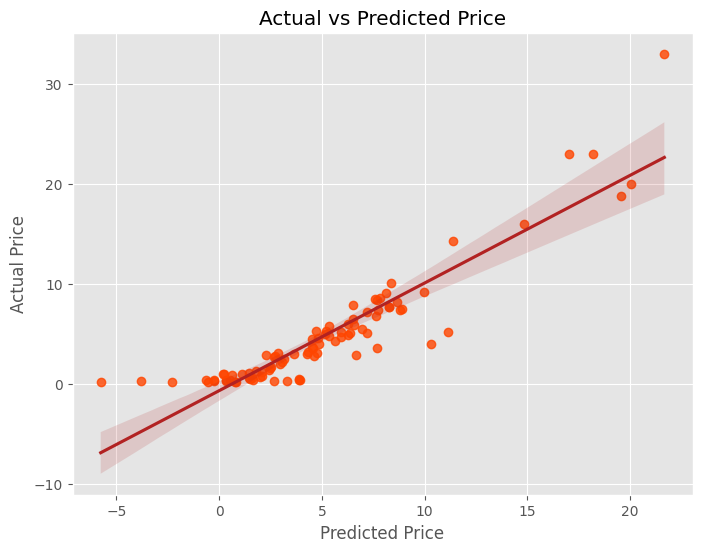

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize=(8, 6))
sns.regplot(x=y_pred, y=y_test,
            scatter_kws={"color": "orangered"},
            line_kws={"color": "firebrick"})

plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs Predicted Price')

plt.show()